<a href="https://colab.research.google.com/github/sgruyzcki/DiploDatos2026/blob/main/Aprendizaje%20Supervisado/Practico%201/AS_2026_Entregable_Grupo_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**

### Grupo 3:

- Mariano Baggini
- DA SILVA, Rocio
- GRUZYCKI, Sergio
- NEDEL, Agustina

---
## Kaggle Competition: Clasificación de imágenes de rostros con o sin barbijos

**Objetivos especificos**:

- Explorar los datos y aprender de ellos.
- Probar diferentes modelos y ver cuáles ajustan mejor dado los datos.
- Para esta competencia se elige como métrica el **balanced_accuracy_score**. Discutir, analizar y justificar porque es necesaria está métrica para este problema.
- **Obtener una métrica mejor que la que se presenta en este ejemplo.**
- Tratar de obtener un score lo más alto posible!
- Discutir la elección de modelo.

NOTA: El análisis exploratorio y el preprocesamiento de los datos queda a libertad de cada grupo y no deben quedarse con este simple ejemplo.

In [1]:
# Librerias usadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, ConfusionMatrixDisplay, classification_report, precision_score, accuracy_score, balanced_accuracy_score, f1_score
from sklearn.decomposition import PCA
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

sns.set_context('talk')

## 1. Carga de datos


### 1.1 Datos de entrenamiento

Cargamos los datos de entrenamiento que vamos a utilizar para generar nuestro modelo.

***Atributos del dataset:***

- `Id`: identificador unico de la imagen.
- `Clase`: etiqueta objetivo: ccb (cara con barbijo) o csb (cara sin barbijo).
- `bb_width`: ancho del recorte de la cara (bounding box).
- `bb_height`: alto de recorte de la cara.
- `ch_RGB`: promedio del histograma de los tres canales de color RGB.
- `1097`, `595`, ...: vector de caracteristicas numéricas extraído por la red convolucional.

In [2]:
train_url = 'https://raw.githubusercontent.com/DiploDatos/AprendizajeSupervisado/master/Pr%C3%A1ctico/mask_prediction_datasetDrop_train-labeled2.csv'
train_data = pd.read_csv(train_url, delimiter=';')

In [3]:
train_df = train_data.copy()
train_df.head(2)

,id,clase,bb_width,bb_height,ch_RGB,1097,595,1088,1078,1703,...,1152,1428,182,488,1369,582,570,2022,1966,198
0,1,ccb,118,167,126.002029,0.171342,0.254909,1.729943,0.872499,0.645055,...,0.000246,0.081324,0.391930,0.247319,0.033110,0.394890,0.204616,1.668020,0.052727,0.302152
1,2,ccb,286,396,152.522842,0.172407,0.217375,2.900968,0.421334,0.270867,...,0.056044,0.059036,0.123057,0.462978,0.037138,0.658777,0.172517,0.507375,0.274298,0.648528


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1884 entries, 0 to 1883
Columns: 438 entries, id to 198
dtypes: float64(434), int64(3), object(1)
memory usage: 6.3+ MB


La columna `clase` es la columna que debemos predecir. En el dataset de Test esta columna tiene valores nulos.

### 1.2 Datos de testeo

Cargamos los datos de test. Estos datos son los que van a utilizar para predecir si las personas tienen barbijos colocados en el rostro y generar alrchivo `submision.csv` para utilizar en la competencia de Kaggle.

In [5]:
test_url = 'https://raw.githubusercontent.com/DiploDatos/AprendizajeSupervisado/master/Pr%C3%A1ctico/mask_prediction_datasetDrop_test2.csv'
test_data = pd.read_csv(test_url, delimiter=',')

In [6]:
test_df = test_data.copy()
test_df.head(2)

,id,clase,bb_width,bb_height,ch_RGB,1097,595,1088,1078,1703,...,1152,1428,182,488,1369,582,570,2022,1966,198
0,1,NaN,73,90,204.171544,0.217586,0.391318,2.419429,0.147021,0.379218,...,0.195664,0.063082,0.289413,0.381645,0.000748,0.35289,0.121977,0.953930,0.237596,0.864902
1,2,NaN,122,125,140.457654,0.185056,0.474035,0.154145,0.126471,0.039147,...,0.073346,0.080111,0.477455,0.205951,0.075715,0.21614,0.746478,0.329009,0.019684,0.249253


In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524 entries, 0 to 523
Columns: 438 entries, id to 198
dtypes: float64(435), int64(3)
memory usage: 1.8 MB


### 1.3 Consideraciones generales

Cada fila representa la imagen de una cara ya procesada por la ResNet. Las columnas `bb_width`, `bb_height` y `ch_RGB` son features interpretables, mientras que el resto son las 434 activaciones extraídas por la red convolucional. Si bien estas no tienen una interpretacion individual directa, se utilizan para capturar patrones visuales aprendidos por el modelo.

Recapitulando el tamaño de los datasets:

In [8]:
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (1884, 438)
Test shape : (524, 438)


## 2. Analisis de los datos

### 2.1 Exploracion inicial

In [9]:
resnet_cols = [c for c in train_df.columns if c not in ['id', 'clase', 'bb_width', 'bb_height', 'ch_RGB']]

In [10]:
# Nulos en train y test
print("Nulos en train:", train_df.isnull().sum().sum())
print("Nulos en test :", test_df.isnull().sum().sum())
print("\nNulos por columna en test (solo las que tienen):")
print(test_df.isnull().sum()[test_df.isnull().sum() > 0])

Nulos en train: 0
Nulos en test : 524

Nulos por columna en test (solo las que tienen):
clase    524
dtype: int64


Se observa que el conjunto de entrenamiento no tiene ningún valor nulo. Por otro lado, el conjunto test tiene la columna de interes `clase` vacía a propósito. Las demás features están completas en ambos conjuntos, no es necesario imputar.

In [11]:
# Estudio de duplicados
print("Filas duplicadas (train) :", train_df.duplicated().sum())
print("IDs duplicados   (train) :", train_df['id'].duplicated().sum())
print("IDs duplicados    (test) :", test_df['id'].duplicated().sum())

Filas duplicadas (train) : 0
IDs duplicados   (train) : 0
IDs duplicados    (test) : 0


No se encontraron filas ni IDs duplicados en train ni test.

In [12]:
# Estadisticas descriptivas
train_df.describe()

,id,bb_width,bb_height,ch_RGB,1097,595,1088,1078,1703,1448,...,1152,1428,182,488,1369,582,570,2022,1966,198
count,1884.000000,1884.000000,1884.00000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,...,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000
mean,942.500000,101.909236,133.47983,114.109534,0.168035,0.400830,1.690452,0.296696,0.445435,0.442737,...,0.066285,0.171946,0.215352,0.416790,0.085017,0.320012,0.318657,0.693318,0.223473,0.250213
std,544.008272,91.933372,119.15816,30.696614,0.126249,0.273933,1.219991,0.213530,0.406341,0.284700,...,0.069526,0.179459,0.209379,0.278408,0.086755,0.221458,0.231352,0.457887,0.116369,0.161713
min,1.000000,11.000000,12.00000,40.301282,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000246,0.000000,0.000648,0.000000,0.001931,0.007359,0.000000
25%,471.750000,48.750000,59.00000,92.309942,0.075003,0.199049,0.547147,0.135446,0.115591,0.237259,...,0.015967,0.058051,0.064764,0.194096,0.023932,0.152957,0.141901,0.331458,0.133532,0.129353
50%,942.500000,71.000000,88.00000,109.841245,0.143056,0.336917,1.631053,0.251868,0.342227,0.381312,...,0.045157,0.119384,0.147675,0.360841,0.057883,0.271596,0.274714,0.618690,0.214287,0.219952
75%,1413.250000,120.000000,167.00000,134.545488,0.234480,0.541367,2.653032,0.400949,0.644068,0.569638,...,0.095316,0.217514,0.307282,0.593489,0.117845,0.435103,0.450637,0.946997,0.296023,0.336383
max,1884.000000,1296.000000,1070.00000,202.392985,0.991374,1.821444,5.263674,1.397370,2.541877,2.500119,...,0.538534,1.363758,1.493638,1.545518,0.859438,1.943598,1.753040,3.450385,0.627220,1.135739


Se observa que `bb_width` y `bb_height` tienen rangos muy amplios (de 11 a 1296 y de 12 a 1070), lo que indica que hay tamaño dispares según la resolución del video/frame original. Las features de la ResNet están en escalas más pequeñas y homogéneas entre sí. Estudiamos en mayor detalle los features interpretables:

In [13]:
train_df[['bb_width', 'bb_height', 'ch_RGB']].describe()

,bb_width,bb_height,ch_RGB
count,1884.000000,1884.00000,1884.000000
mean,101.909236,133.47983,114.109534
std,91.933372,119.15816,30.696614
min,11.000000,12.00000,40.301282
25%,48.750000,59.00000,92.309942
50%,71.000000,88.00000,109.841245
75%,120.000000,167.00000,134.545488
max,1296.000000,1070.00000,202.392985


Al observar las columnas, se nota una diferencia de escalas entre columnas. Esto da la pauta de la necesidad de estandarizacion posterior.

### 2.2 Estudio de desbalance

Veamos de que manera se distribuyen los datos en los valores del feature objetivo: `clase`.

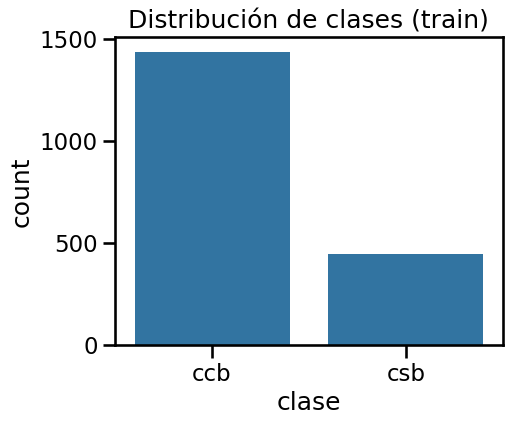

In [14]:
# Estudio de desbalance
plt.figure(figsize=(5,4))
sns.countplot(data=train_df, x='clase')
plt.title('Distribución de clases (train)')
plt.show()

In [15]:
# Distribucion de datos
conteo = train_df['clase'].value_counts()
porcentaje = (train_df['clase'].value_counts(normalize='True')*100).round(2)

tabla_distribucion = pd.DataFrame({
    'Frecuencia':conteo,
    'Porcentaje (%)':porcentaje
})

tabla_distribucion

,Frecuencia,Porcentaje (%)
clase,,
ccb,1436,76.22
csb,448,23.78


Debido al desbalance presente (relacion 4:1), es de gran importancia que el modelo sea preciso al identificar la clase minoritaria. De otra forma, sus metricas resultan engañosas aunque sean elevadas.

### 2.3 EDA: Essential features

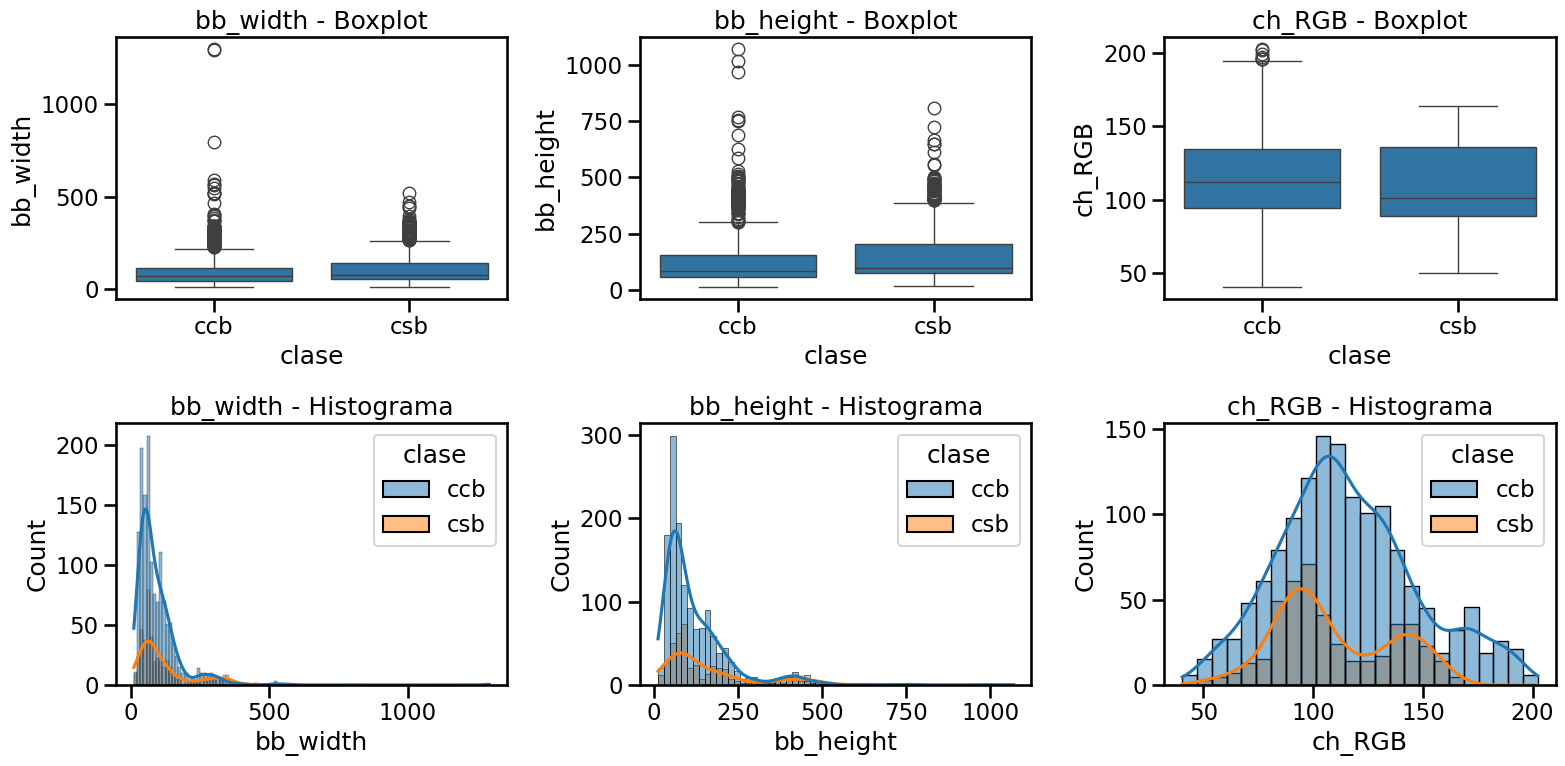

In [16]:
# Distribución de features por clase
features_simples = ['bb_width', 'bb_height', 'ch_RGB']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, col in enumerate(features_simples):
    sns.boxplot(data=train_df, x='clase', y=col, ax=axes[0,i])
    axes[0,i].set_title(f'{col} - Boxplot')

    sns.histplot(data=train_df, x=col, hue='clase', kde=True, ax=axes[1,i])
    axes[1,i].set_title(f'{col} - Histograma')
plt.tight_layout()
plt.show()

Tanto en `bb_width` como en `bb_height`, la clase *csb* presenta medianas levemente más altas que *ccb*, aunque las cajas se superponen significativamente y ambas clases tienen colas largas de valores atípicos. En `ch_RGB` las distribuciones de ambas clases son idénticas, por lo que el color promedio parece no discriminar bien entre tener o no tener barbijo.

Los histogramas demuestran que se ve una superposición entre *ccb* y *csb* en las 3 features, con la clases *ccb* dominando por ser mayoritaria.

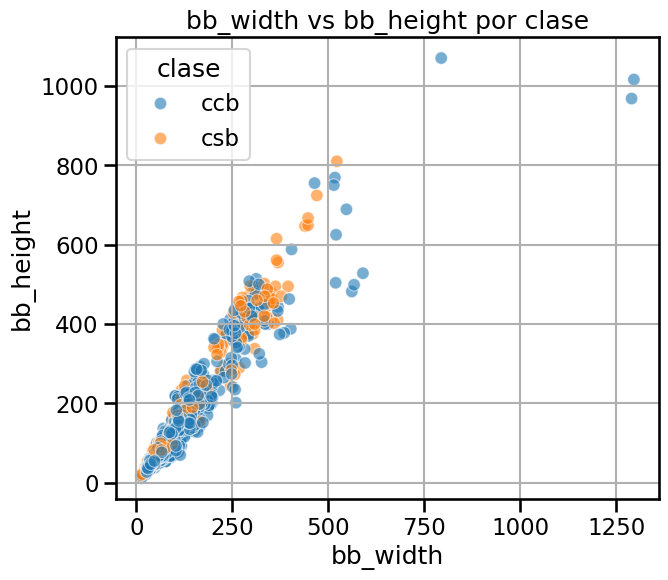

In [17]:
# Relacion entre bounding box
plt.figure(figsize=(7,6))
sns.scatterplot(data=train_df, x='bb_width', y='bb_height', hue='clase', alpha=0.6)
plt.title('bb_width vs bb_height por clase')
plt.grid()
plt.show()

Se observa una relacion lineal entre `bb_width` y `bb_height`, como era de esperarse. No se observa una separación clara entre clases, los puntos están entremezclados.

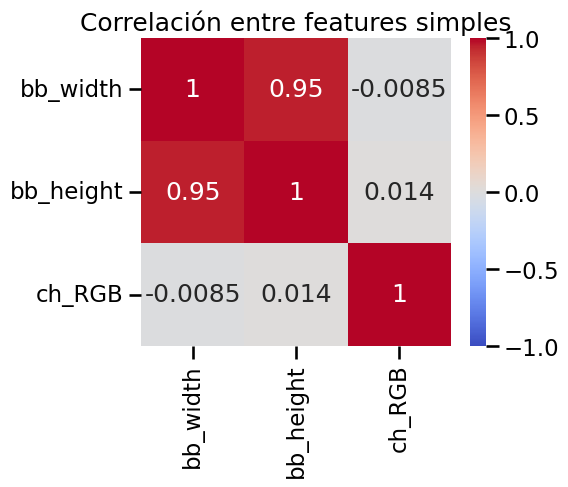

In [18]:
# Correlacion entre features simple
plt.figure(figsize=(5,4))
sns.heatmap(train_df[features_simples].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre features simples')
plt.show()

Se ve que `bb_width` y `bb_height` están correlacionados entre sí, ambas aportan la misma información. Podría considerarse combinarlas en una sola feature, pero por el momento no se hará esto. Por otro lado, `ch_RGB` no tiene correlación con ninguna de las dos, es una feature independiente del tamaño.

Features con menor varianza:
273     0.002161
1379    0.004530
1152    0.004834
1200    0.005330
1138    0.006626
748     0.007087
1369    0.007526
1976    0.008188
1463    0.008443
1823    0.008900
dtype: float64


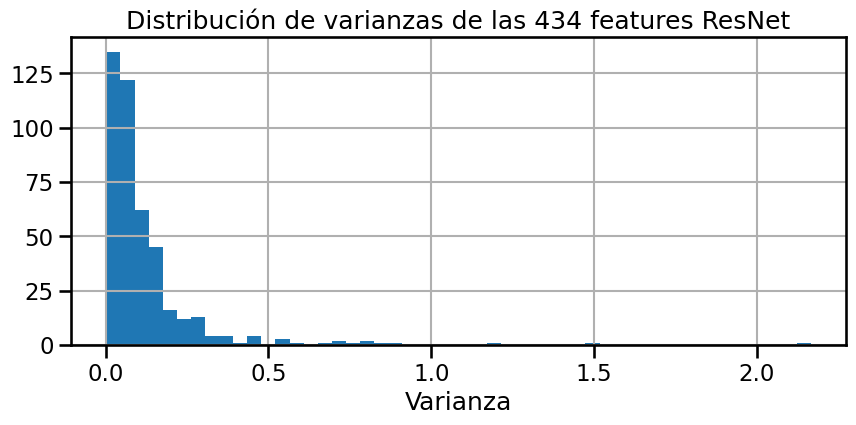

In [19]:
# Analisis de las features de la ResNet
variances = train_df[resnet_cols].var().sort_values()
print("Features con menor varianza:")
print(variances.head(10))

plt.figure(figsize=(10,4))
plt.hist(variances, bins=50)
plt.title('Distribución de varianzas de las 434 features ResNet')
plt.xlabel('Varianza')
plt.grid()
plt.show()

La gran mayoría de las 434 features de la ResNet tiene varianza muy baja, solo algunas superan la varianza 0.5. En una red neuronal se esperan que muchas neuronas respondan débilmente o de forma casi constante ante la mayoría de imágenes, mientras que pocas concentran la mayor parte de la variabilidad útil.

In [20]:
# Estudio de correlacion alta entre pares
corr_matrix = train_df[resnet_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, idx, upper.loc[idx, col])
                    for col in upper.columns for idx in upper.index
                    if pd.notna(upper.loc[idx, col]) and upper.loc[idx, col] > 0.9]
print(f"Pares de features con correlación > 0.9: {len(high_corr_pairs)}")

Pares de features con correlación > 0.9: 0


No se encontraron pares de features con correlación mayor a 0.9. Esto indica que las features de la ResNet no son redundantes entre sí y cada una aporta información distinta. No se elimina columnas por multicolinealidad.

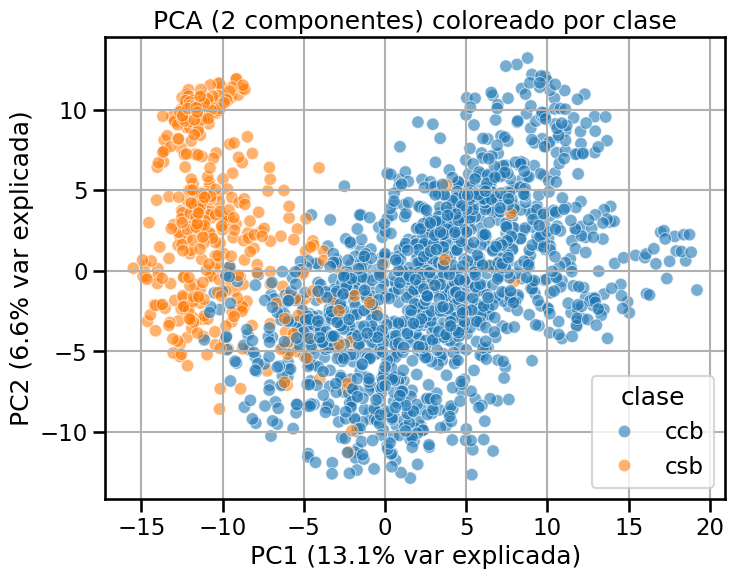

In [21]:
# Visualizacion en baja dimension
X_vis = StandardScaler().fit_transform(train_df[resnet_cols])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_vis)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=train_df['clase'], alpha=0.6)
plt.title('PCA (2 componentes) coloreado por clase')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var explicada)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var explicada)')
plt.grid()
plt.show()

El PCA muestra una separación más marcada, gran parte de los puntos *csb* (naranja) se agrupan en una región bien diferenciada, mientras que *ccb* (azul) ocupa una región más amplia hacia la derecha y abajo. Hay una porción en la que ambos puntos se mezclan, por lo que la separación es parcial.

Los 2 componentes explican apenas el 19,7% de la varianza total.

### 2.4. Evaluación de parámetros altos

In [22]:
# Comparacion de distribucion train vs test
comparacion = pd.DataFrame({
    'train_mean': train_df[features_simples].mean(),
    'test_mean': test_df[features_simples].mean(),
    'train_std': train_df[features_simples].std(),
    'test_std': test_df[features_simples].std(),
})
comparacion

,train_mean,test_mean,train_std,test_std
bb_width,101.909236,75.150763,91.933372,55.612066
bb_height,133.479830,93.467557,119.158160,71.920479
ch_RGB,114.109534,251.353361,30.696614,1902.441581


Se observa en `ch_RGB` la media (251.4) y el desvío estándar (1902) en test es más grande que la media (114.1) y el desvío estándar (30.7) train. Esto indica que el conjunto de test podría tener condiciones de iluminación o preprocesamiento distinto a los de train.

El Standarscaler debe ajustarse con los datos de train y luego aplicarse transform sobre test con esos mismos parámetros.

12     40632.314997
268    16240.642994
520      214.140035
299      213.935298
432      213.328710
374      212.757828
287      211.795685
102      211.550227
425      211.297877
118      209.769516
393      208.872716
503      208.048477
356      205.454971
319      204.199844
0        204.171544
Name: ch_RGB, dtype: float64


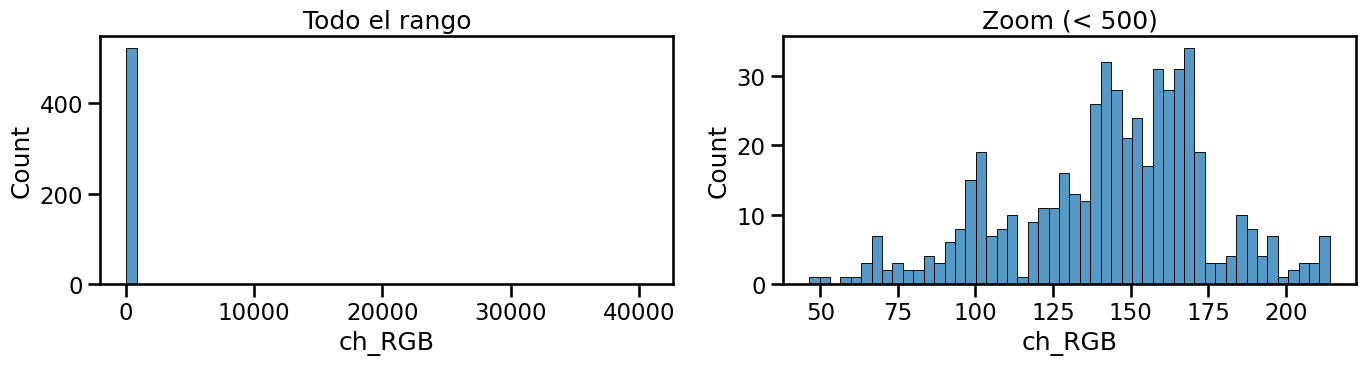

In [23]:
# Ver los valores más altos de ch_RGB en test
print(test_df['ch_RGB'].sort_values(ascending=False).head(15))

# Comparar rango normal (zoom) vs completo
fig, axes = plt.subplots(1, 2, figsize=(14,4))
sns.histplot(test_df['ch_RGB'], bins=50, ax=axes[0])
axes[0].set_title('Todo el rango')

sns.histplot(test_df[test_df['ch_RGB'] < 500]['ch_RGB'], bins=50, ax=axes[1])
axes[1].set_title('Zoom (< 500)')
plt.tight_layout()
plt.show()

Se analiza cuáles son los casos puntuales que generan la diferencia de los valores extremos de test en ch_RGB.

In [24]:
# Casos mas extremos de ch_RGB en test
extremos_test = test_df.sort_values('ch_RGB', ascending=False).head(5)[['id', 'ch_RGB', 'bb_width', 'bb_height']]
extremos_test

,id,ch_RGB,bb_width,bb_height
12,13,40632.314997,25,32
268,269,16240.642994,16,22
520,521,214.140035,68,81
299,300,213.935298,64,83
432,433,213.328710,62,86


Se observan que las dos primeras filas presentan órdenes de magnitud por encima del resto.

Se propone utilizar una cota que surge de la naturaleza de la variable. Por definición, ch_RGB es el promedio del histograma de los 3 canales de color, y una imagen estándar de 8 bits tiene valores de intensidad entre 0 y 255 en cada canal, por lo tanto cualquier valor por encima de 255 no puede ser un promedio de píxeles válido.

Para no perder información real de train, se evita utilizar el percentil 99 ya que marca como outlier al 1% superior de la distribución de train, que en este caso, corresponden a 19 filas en train que no son errores, son la cola normal de la variable.

In [25]:
# limite superior
limite_superior = 255.0

filas_train_afectadas = (train_df['ch_RGB'] > limite_superior).sum()
filas_test_afectadas = (test_df['ch_RGB'] > limite_superior).sum()
print(f"Limite superior (maximo teorico de un promedio RGB de 8 bits): {limite_superior}")
print(f"Filas de train por encima del limite: {filas_train_afectadas} ({filas_train_afectadas/len(train_df)*100:.2f}% del total)")
print(f"Filas de test  por encima del limite: {filas_test_afectadas} ({filas_test_afectadas/len(test_df)*100:.2f}% del total)")

Limite superior (maximo teorico de un promedio RGB de 8 bits): 255.0
Filas de train por encima del limite: 0 (0.00% del total)
Filas de test  por encima del limite: 2 (0.38% del total)


Con este criterio, no se modifica ninguna fila en train, ya que todos los valores están dentro del rango, y se recorta las dos filas que presentan anomalías.

Antes de aplicar el recorte, se evalua que tan grave es no hacerlo. Se calcula a que z-score quedarían esas filas si se estandarizan tal cual, contra el z-score si primero se recortan.

In [26]:
# z-score con y sin recorte usando media/std de train
media_train = train_df['ch_RGB'].mean()
std_train = train_df['ch_RGB'].std()

comparacion_z = test_df.sort_values('ch_RGB', ascending=False).head(5)[['id', 'ch_RGB']].copy()
comparacion_z['z_sin_recorte'] = (comparacion_z['ch_RGB'] - media_train) / std_train
comparacion_z['z_con_recorte'] = (comparacion_z['ch_RGB'].clip(upper=limite_superior) - media_train) / std_train
comparacion_z

,id,ch_RGB,z_sin_recorte,z_con_recorte
12,13,40632.314997,1319.956847,4.589772
268,269,16240.642994,525.352197,4.589772
520,521,214.140035,3.258682,3.258682
299,300,213.935298,3.252012,3.252012
432,433,213.328710,3.232252,3.232252


Sin recorte, las 2 filas realmente extremas quedan con z-scores fuera de escala, que en un modelo basado en distancias como SVM esto podría afectar la predicción. Con el recorte, el z queda en un valor alto, pero estando dentro del orden. Nótese que las demás filas no se ven afectadas por este recorte.

Se aplica el recorte a ch_RGB.

In [27]:
# Aplicamos el clip a train y test con el mismo limite (ajustado solo con train)
train_df['ch_RGB'] = train_df['ch_RGB'].clip(upper=limite_superior)
test_df['ch_RGB'] = test_df['ch_RGB'].clip(upper=limite_superior)

print("Nuevo maximo ch_RGB train:", train_df['ch_RGB'].max())
print("Nuevo maximo ch_RGB test :", test_df['ch_RGB'].max())

print('Media ch_RGB train:', train_df['ch_RGB'].mean())
print('Media ch_RGB test:', test_df['ch_RGB'].mean())

Nuevo maximo ch_RGB train: 202.392985026042
Nuevo maximo ch_RGB test : 255.0
Media ch_RGB train: 114.1095339325583
Media ch_RGB test: 143.79046371935587


### 2.5 Codificacion de `clase`

In [28]:
# Mapeo de valores. Valido porque estan acotadas
mapeo_directo = {'ccb': 1, 'csb': 0}
train_df['clase'] = train_df['clase'].map(mapeo_directo)

# Verificacion
train_df['clase'].value_counts()

,count
clase,
1,1436
0,448


### 2.6. Preparacion de datasets

In [29]:
# Aislo la variable objetivo: clase
y = train_df.clase
X = train_df.drop('clase',axis=1)
X.head(3)

,id,bb_width,bb_height,ch_RGB,1097,595,1088,1078,1703,1448,...,1152,1428,182,488,1369,582,570,2022,1966,198
0,1,118,167,126.002029,0.171342,0.254909,1.729943,0.872499,0.645055,0.141102,...,0.000246,0.081324,0.391930,0.247319,0.033110,0.394890,0.204616,1.668020,0.052727,0.302152
1,2,286,396,152.522842,0.172407,0.217375,2.900968,0.421334,0.270867,0.213251,...,0.056044,0.059036,0.123057,0.462978,0.037138,0.658777,0.172517,0.507375,0.274298,0.648528
2,3,123,167,93.290398,0.139690,0.759909,0.081340,0.325830,0.018619,0.170640,...,0.021488,0.350511,0.165781,0.114810,0.154125,0.193874,0.393903,0.170703,0.099427,0.344505


In [30]:
# Separacion de la columna con los Id de las imágenes en una sola variable:
imagenID = X.id
X.drop('id',axis=1,inplace=True)

In [31]:
# Estandarizado de variables:
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0, stratify=y)

scaler = StandardScaler()
x_train = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns, index=x_train.index)
x_test  = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns, index=x_test.index)

Con esto, separamos los datasets de entrenamiento y testeo:

In [32]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1507 entries, 1711 to 1608
Columns: 436 entries, bb_width to 198
dtypes: float64(436)
memory usage: 5.0 MB


In [33]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 377 entries, 726 to 306
Columns: 436 entries, bb_width to 198
dtypes: float64(436)
memory usage: 1.3 MB


**IMPORTANTE**: Luego de seleccionar el modelo, es necesario replicar el preprocesamiento anterior para el dataset de testeo `test_df` para evirar data leakage.

## 3. Planteo de modelos

In [34]:
# Definicion de semilla
seed = 42 # Coincide con la de split

# Inicializacion de modelos de interes con balanceo de peso
models = [
    LogisticRegression(random_state=seed, class_weight='balanced', max_iter=1000),
    SVC(random_state=seed, class_weight='balanced'),
    RandomForestClassifier(random_state=seed, class_weight='balanced'),
    XGBClassifier(eval_metric='logloss', random_state=seed)
]

names = ['Regresión Logística', 'SVM (RBF)', 'Random Forest', 'XGBoost']

# Diccionario para almacenar métricas
resultados = []
trained_models = {}

In [35]:
for clf, name in zip(models, names):
    # Entrenar
    clf.fit(x_train, y_train)
    trained_models[name] = clf  # Guardamos el modelo por su nombre

    # Predicciones
    train_preds = clf.predict(x_train)
    test_preds = clf.predict(x_test)

    # Calculo de métricas
    metricas = {
        'Modelo': name,
        'Balanced Accuracy Train': balanced_accuracy_score(y_train, train_preds),
        'Balanced Accuracy Test ': balanced_accuracy_score(y_test, test_preds),
        'Recall (csb)': recall_score(y_test, test_preds, pos_label=0), # <--- Captura la clase minoritaria
        'Recall (ccb)': recall_score(y_test, test_preds, pos_label=1),
        'F1-Score (Macro)': f1_score(y_test, test_preds, average='macro')
    }

    resultados.append(metricas)

# Conversion a DataFrame
df_resultados = pd.DataFrame(resultados).set_index('Modelo')
df_resultados = (df_resultados * 100).round(2)
df_resultados

,Balanced Accuracy Train,Balanced Accuracy Test,Recall (csb),Recall (ccb),F1-Score (Macro)
Modelo,,,,,
Regresión Logística,100.00,99.65,100.00,99.30,99.28
SVM (RBF),99.87,98.54,97.78,99.30,98.54
Random Forest,100.00,93.54,87.78,99.30,95.08
XGBoost,100.00,97.08,95.56,98.61,97.08


### 3.2 Validación cruzada

In [36]:
from sklearn.pipeline import Pipeline

cv_estrategia = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

resultados_cv = []
for clf, name in zip(models, names):
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    ba_scores = cross_val_score(pipe, X, y, cv=cv_estrategia, scoring='balanced_accuracy')
    resultados_cv.append({
        'Modelo': name,
        'Balanced Acc CV (media)': ba_scores.mean() * 100,
        'Balanced Acc CV (std)': ba_scores.std() * 100,
    })

tabla_cv = pd.DataFrame(resultados_cv).sort_values('Balanced Acc CV (media)', ascending=False).reset_index(drop=True)
tabla_cv.round(2)

,Modelo,Balanced Acc CV (media),Balanced Acc CV (std)
0,Regresión Logística,98.42,0.80
1,SVM (RBF),98.26,0.72
2,XGBoost,96.53,1.18
3,Random Forest,94.62,0.70


In [37]:
# Baseline: árbol de decisión simple
baseline_pipe = Pipeline([('scaler', StandardScaler()), ('clf', DecisionTreeClassifier(random_state=seed))])
baseline_scores = cross_val_score(baseline_pipe, X, y, cv=cv_estrategia, scoring='balanced_accuracy')

print(f"Baseline (Árbol de decisión): {baseline_scores.mean()*100:.2f}% (+/- {baseline_scores.std()*100:.2f}%)")

mejor_modelo_nombre = tabla_cv.iloc[0]['Modelo']
mejor_score = tabla_cv.iloc[0]['Balanced Acc CV (media)']
print(f"Mejor modelo ({mejor_modelo_nombre}): {mejor_score:.2f}%")
print(f"Mejora sobre baseline: +{mejor_score - baseline_scores.mean()*100:.2f} puntos")

Baseline (Árbol de decisión): 94.02% (+/- 0.82%)
Mejor modelo (Regresión Logística): 98.42%
Mejora sobre baseline: +4.41 puntos


### 3.3. Ajuste de Hiperparámetros

In [38]:
# Grilla de parámetros
param_grid_svm = [
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'class_weight': ['balanced']
    },
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100],
        'class_weight': ['balanced']
    }
]

# Configuracion del GridSearch
svm_base = SVC(random_state=seed)
cv_estrategia = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

grid_search_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid_svm,
    scoring='balanced_accuracy', # Uso del scorer definido para identificar clases minoritarias
    cv=cv_estrategia,
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
grid_search_svm.fit(x_train, y_train)

print("Mejor Balanced Accuracy obtenido en CV: %.2f%%" % (grid_search_svm.best_score_ * 100))
print("Mejores parámetros para tu SVM final:", grid_search_svm.best_params_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejor Balanced Accuracy obtenido en CV: 98.45%
Mejores parámetros para tu SVM final: {'C': 1, 'class_weight': 'balanced', 'gamma': 0.001, 'kernel': 'rbf'}


In [39]:
# Grilla de parámetros para Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_base = RandomForestClassifier(random_state=seed)
cv_busqueda = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)


grid_search_rf = RandomizedSearchCV(
    rf_base, param_grid_rf, n_iter=8,
    scoring='balanced_accuracy', cv=cv_busqueda,
    n_jobs=-1, random_state=seed
)

grid_search_rf.fit(x_train, y_train)

print("Mejor Balanced Accuracy obtenido en CV: %.2f%%" % (grid_search_rf.best_score_ * 100))
print("Mejores parámetros para Random Forest:", grid_search_rf.best_params_)

Mejor Balanced Accuracy obtenido en CV: 95.65%
Mejores parámetros para Random Forest: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 15, 'class_weight': 'balanced'}


In [40]:
# Grilla de parámetros para Regresión Logística
param_grid_logreg = [
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs'],
        'class_weight': ['balanced']
    },
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear'],
        'class_weight': ['balanced']
    }
]

logreg_base = LogisticRegression(random_state=seed, max_iter=1000)

grid_search_logreg = GridSearchCV(
    estimator=logreg_base,
    param_grid=param_grid_logreg,
    scoring='balanced_accuracy',
    cv=cv_estrategia,
    n_jobs=-1,
    verbose=1
)

grid_search_logreg.fit(x_train, y_train)

print("Mejor Balanced Accuracy obtenido en CV: %.2f%%" % (grid_search_logreg.best_score_ * 100))
print("Mejores parámetros para Regresión Logística:", grid_search_logreg.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejor Balanced Accuracy obtenido en CV: 98.46%
Mejores parámetros para Regresión Logística: {'C': 100, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}


In [41]:
# Grilla de parámetros para XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

xgb_base = XGBClassifier(eval_metric='logloss', random_state=seed)

grid_search_xgb = RandomizedSearchCV(
    xgb_base,
    param_grid_xgb,
    n_iter=8,
    scoring='balanced_accuracy',
    cv=cv_estrategia,
    n_jobs=-1,
    random_state=seed
)

grid_search_xgb.fit(x_train, y_train)

print("Mejor Balanced Accuracy obtenido en CV: %.2f%%" % (grid_search_xgb.best_score_ * 100))
print("Mejores parámetros para XGBoost:", grid_search_xgb.best_params_)

Mejor Balanced Accuracy obtenido en CV: 96.95%
Mejores parámetros para XGBoost: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.2}


### 3.4. Comparación Final

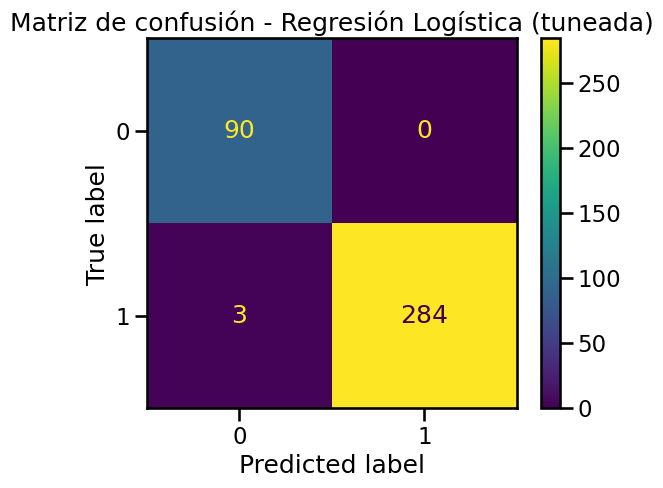

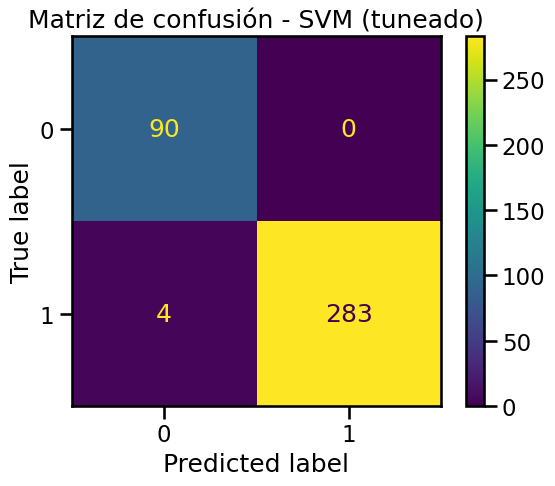

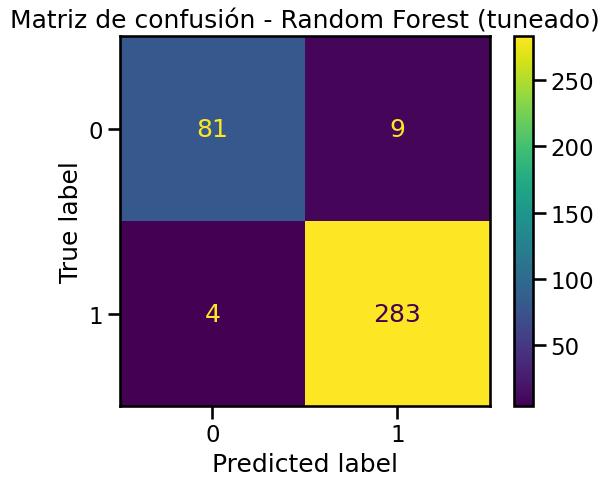

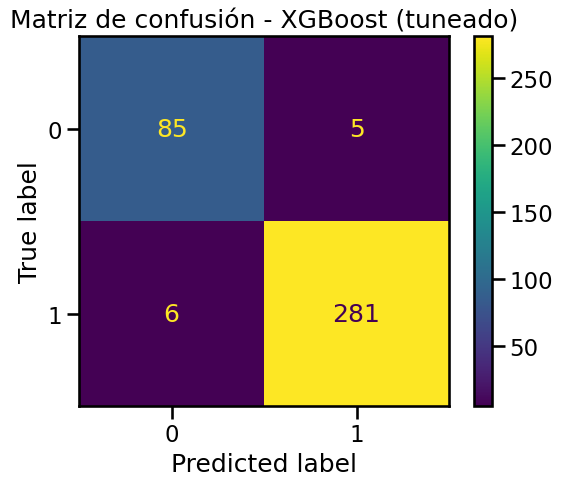

,Balanced Accuracy Test,Recall (csb),Recall (ccb),F1-Score (Macro)
Modelo,,,,
Regresión Logística (tuneada),99.48,100.00,98.95,98.92
SVM (tuneado),99.30,100.00,98.61,98.56
XGBoost (tuneado),96.18,94.44,97.91,96.00
Random Forest (tuneado),94.30,90.00,98.61,95.16


In [42]:
modelos_finales = {
    'Regresión Logística (tuneada)': grid_search_logreg.best_estimator_,
    'SVM (tuneado)': grid_search_svm.best_estimator_,
    'Random Forest (tuneado)': grid_search_rf.best_estimator_,
    'XGBoost (tuneado)': grid_search_xgb.best_estimator_,
}

resultados_finales = []
for nombre, modelo in modelos_finales.items():
    preds = modelo.predict(x_test)
    resultados_finales.append({
        'Modelo': nombre,
        'Balanced Accuracy Test': balanced_accuracy_score(y_test, preds) * 100,
        'Recall (csb)': recall_score(y_test, preds, pos_label=0) * 100,
        'Recall (ccb)': recall_score(y_test, preds, pos_label=1) * 100,
        'F1-Score (Macro)': f1_score(y_test, preds, average='macro') * 100,
    })

    ConfusionMatrixDisplay.from_predictions(y_test, preds)
    plt.title(f'Matriz de confusión - {nombre}')
    plt.show()

df_finales = pd.DataFrame(resultados_finales).set_index('Modelo').round(2)
df_finales.sort_values('Balanced Accuracy Test', ascending=False)